In [1]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")

# Offline fallback
df.to_csv("titanic.csv", index=False)

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
df.info()

df.describe()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


(891, 15)

In [3]:
missing = df.isnull().mean()*100

missing[missing > 0]

,0
age,19.865320
embarked,0.224467
deck,77.216611
embark_town,0.224467


In [4]:
df_clean = df.copy()

# Drop high missing column
df_clean.drop(columns=["deck"], inplace=True)

# Drop rows where missing <5%
df_clean.dropna(subset=["embarked","embark_town"], inplace=True)

# Impute age
df_clean["age"].fillna(
    df_clean["age"].median(),
    inplace=True
)

/tmp/ipykernel_659/3175293248.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["age"].fillna(


In [6]:
df_clean.to_csv("titanic_clean.csv", index=False)

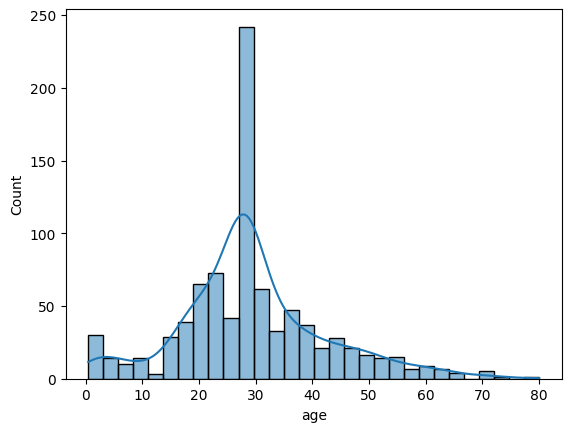

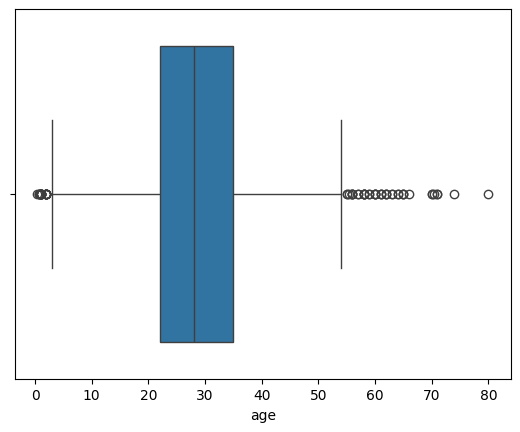

In [7]:
import matplotlib.pyplot as plt

sns.histplot(df_clean["age"], kde=True)
plt.show()


sns.boxplot(x=df_clean["age"])
plt.show()

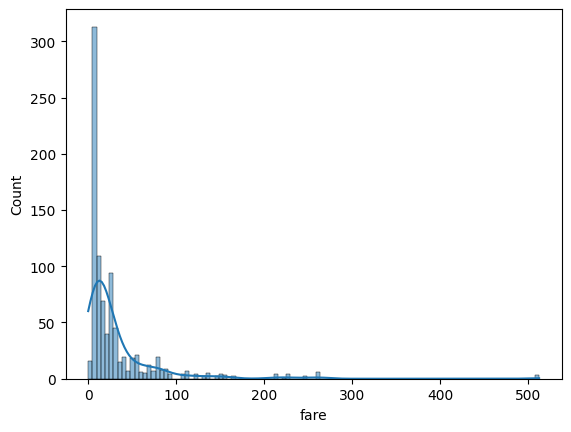

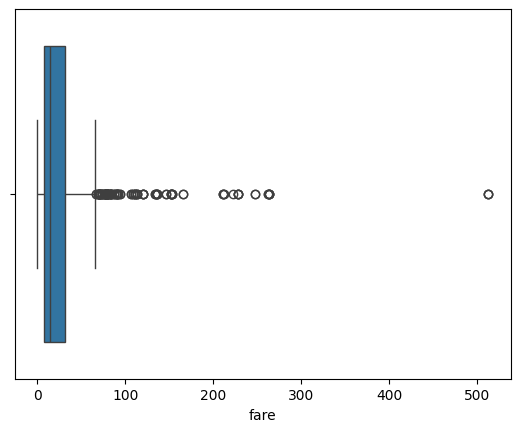

In [8]:
sns.histplot(df_clean["fare"], kde=True)
plt.show()


sns.boxplot(x=df_clean["fare"])
plt.show()

In [9]:
def count_outliers(column):

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3-Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    return ((df_clean[column]<lower) |
            (df_clean[column]>upper)).sum()


age_outliers=count_outliers("age")
fare_outliers=count_outliers("fare")

age_outliers, fare_outliers

(np.int64(65), np.int64(114))

In [10]:
mean = df_clean.fare.mean()
median = df_clean.fare.median()
mode = df_clean.fare.mode()[0]

mean,median,mode

(np.float64(32.09668087739032), 14.4542, np.float64(8.05))

In [11]:
df_clean.groupby("sex")["survived"].mean()

,survived
sex,
female,0.740385
male,0.188908


In [12]:
df_clean.groupby("pclass")["survived"].mean()

,survived
pclass,
1,0.626168
2,0.472826
3,0.242363


In [13]:
df_clean.groupby(
    ["sex","pclass"]
)["survived"].mean()

sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64

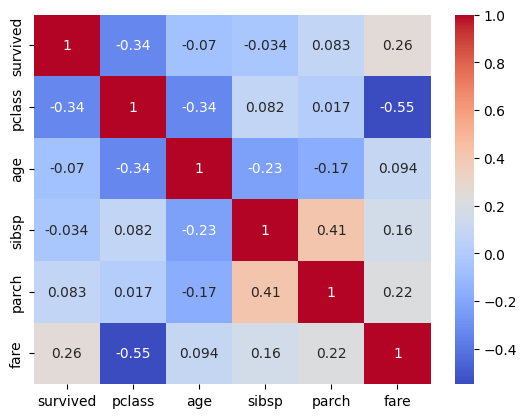

In [14]:
corr_cols=[
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]


corr=df_clean[corr_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [15]:
corr_pairs = (
    corr.where(
        ~pd.DataFrame(
            False,
            index=corr.index,
            columns=corr.columns
        )
    )
)

pairs = (
    corr.abs()
    .unstack()
    .sort_values(
        ascending=False
    )
)

pairs.head(10)

,,0
survived,survived,1.000000
parch,parch,1.000000
age,age,1.000000
pclass,pclass,1.000000
fare,fare,1.000000
sibsp,sibsp,1.000000
pclass,fare,0.548193
fare,pclass,0.548193
sibsp,parch,0.414542
parch,sibsp,0.414542


<Axes: xlabel='sex', ylabel='survived'>

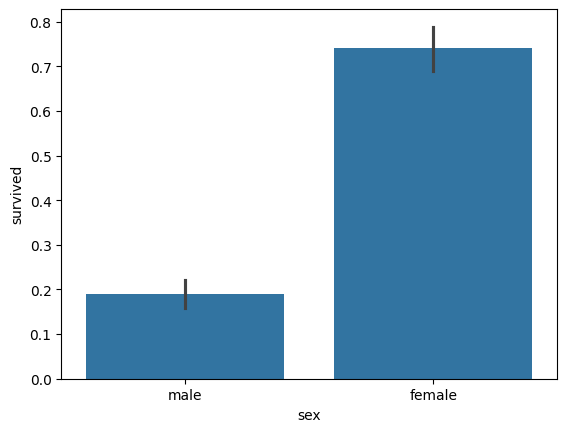

In [16]:
sns.barplot(
    data=df_clean,
    x="sex",
    y="survived"
)

<Axes: xlabel='pclass', ylabel='survived'>

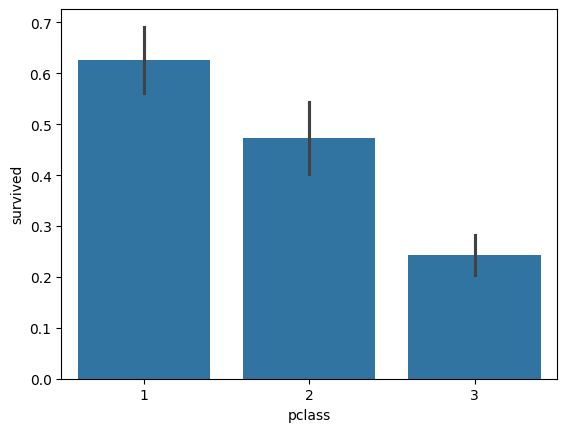

In [17]:
sns.barplot(
    data=df_clean,
    x="pclass",
    y="survived"
)

<Axes: xlabel='survived', ylabel='age'>

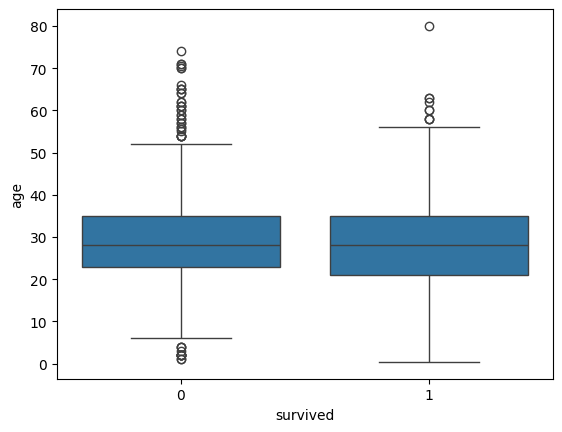

In [18]:
sns.boxplot(
    data=df_clean,
    x="survived",
    y="age"
)

<Axes: xlabel='survived', ylabel='fare'>

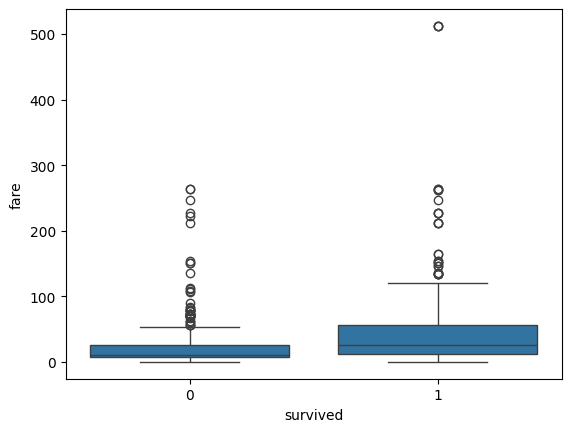

In [19]:
sns.boxplot(
    data=df_clean,
    x="survived",
    y="fare"
)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

scaled=df_clean.copy()

scaled[
    ["age","fare"]
]=scaler.fit_transform(
    df_clean[["age","fare"]]
)


scaled[["age","fare"]].describe()

,age,fare
count,8.890000e+02,8.890000e+02
mean,2.717486e-16,1.398706e-16
std,1.000563e+00,1.000563e+00
min,-2.226536e+00,-6.462044e-01
25%,-5.636741e-01,-4.872378e-01
50%,-1.013399e-01,-3.551972e-01
75%,4.380499e-01,-2.207954e-02
max,3.905556e+00,9.668551e+00


In [21]:
df=pd.read_csv("titanic_clean.csv")

In [22]:
from sklearn.model_selection import train_test_split


X=df.drop("survived",axis=1)
y=df["survived"]


X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
numeric=[
"age",
"sibsp",
"parch",
"fare"
]

categorical=[
"sex",
"embarked"
]

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler


numeric_pipe=Pipeline([
    ("imputer",
     SimpleImputer(strategy="median")),
    ("scale",
     StandardScaler())
])


cat_pipe=Pipeline([
    ("imputer",
     SimpleImputer(strategy="most_frequent")),
    ("encode",
     OneHotEncoder(handle_unknown="ignore"))
])


preprocessor=ColumnTransformer([
    ("num",numeric_pipe,numeric),
    ("cat",cat_pipe,categorical)
])

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


models={

"Logistic Regression":
LogisticRegression(),

"Decision Tree":
DecisionTreeClassifier(),

"Random Forest":
RandomForestClassifier()

}

In [28]:
for name,model in models.items():

    pipe=Pipeline([
        ("prep",preprocessor),
        ("model",model)
    ])

    pipe.fit(X_train,y_train)

In [29]:
for name,model in models.items():

    pipe=Pipeline([
        ("prep",preprocessor),
        ("model",model)
    ])

    pipe.fit(X_train,y_train)

In [30]:
from sklearn.metrics import *

accuracy_score(...)
precision_score(...)
recall_score(...)
f1_score(...)
roc_auc_score(...)

TypeError: missing a required argument: 'y_pred'

In [31]:
from sklearn.tree import plot_tree

plot_tree(
    model,
    feature_names=features,
    class_names=["Dead","Survived"],
    filled=True
)

NameError: name 'features' is not defined

In [32]:
RandomForestClassifier()

RandomForestClassifier()

In [33]:
RandomForestClassifier(
class_weight="balanced"
)

RandomForestClassifier(class_weight='balanced')

In [34]:
from imblearn.over_sampling import SMOTE

smote=SMOTE()

X_train_sm,y_train_sm=smote.fit_resample(
X_train_processed,
y_train
)

NameError: name 'X_train_processed' is not defined

In [35]:
from sklearn.model_selection import GridSearchCV


rf=RandomForestClassifier(
oob_score=True,
random_state=42
)


params={
"n_estimators":[100,200],
"max_depth":[5,10,None],
"max_features":["sqrt","log2"]
}


grid=GridSearchCV(
rf,
params,
cv=5
)


grid.fit(
X_train_processed,
y_train
)


grid.best_params_

grid.best_estimator_.oob_score_

NameError: name 'X_train_processed' is not defined

In [36]:
from sklearn.linear_model import LinearRegression


X=df.drop("fare",axis=1)

y=df["fare"]

In [37]:
from sklearn.metrics import *

MAE
RMSE
R2
Adjusted R2

SyntaxError: invalid syntax (689494210.py, line 6)

In [38]:
sns.scatterplot(
x=y_test,
y=residuals
)

NameError: name 'residuals' is not defined

In [39]:
import joblib


joblib.dump(
best_pipeline,
"best_titanic_pipeline.joblib"
)

NameError: name 'best_pipeline' is not defined

In [40]:
loaded=joblib.load(
"best_titanic_pipeline.joblib"
)


loaded.predict(
X_test.head()
)

FileNotFoundError: [Errno 2] No such file or directory: 'best_titanic_pipeline.joblib'